# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

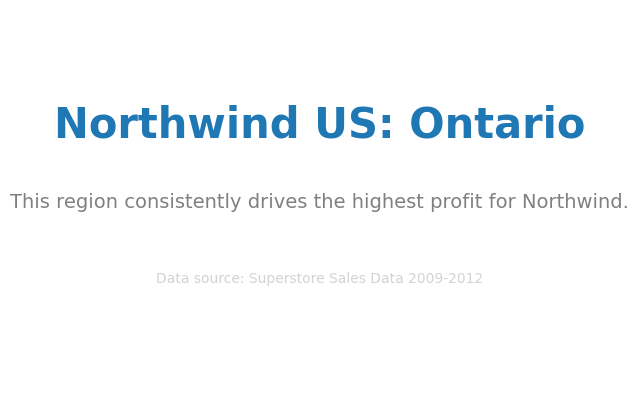

In [2]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# TODO 1: primary element -- large, bold, colored
ax.text(0.5, 0.7, f"Northwind US: {best_region}",
        ha='center', va='center', transform=ax.transAxes,
        fontsize=30, fontweight='bold', color='#1f77b4') # A distinct blue color

# TODO 2: secondary element -- medium, muted color
ax.text(0.5, 0.5,
        "This region consistently drives the highest profit for Northwind.",
        ha='center', va='center', transform=ax.transAxes,
        fontsize=14, color='gray') # Muted gray color

# TODO 3: tertiary element -- small, light gray
ax.text(0.5, 0.3, "Data source: Superstore Sales Data 2009-2012",
        ha='center', va='center', transform=ax.transAxes,
        fontsize=10, color='lightgray') # Light gray color


plt.show()

**Reflection:** Without reading any labels, in what order do your eyes land on the three text elements? If someone glanced at this for only 2 seconds, what's the one fact they'd walk away with?

_Your answer:_
1.  **First:** "Northwind US: Ontario" (the largest, boldest, and colored text)
2.  **Second:** "This region consistently drives the highest profit for Northwind." (the medium-sized, muted gray text)
3.  **Third:** "Data source: Superstore Sales Data 2009-2012" (the smallest, light gray text)

If someone glanced at this for only 2 seconds, they would most likely walk away knowing that **Ontario is the Northwind US region with the highest profit.**

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

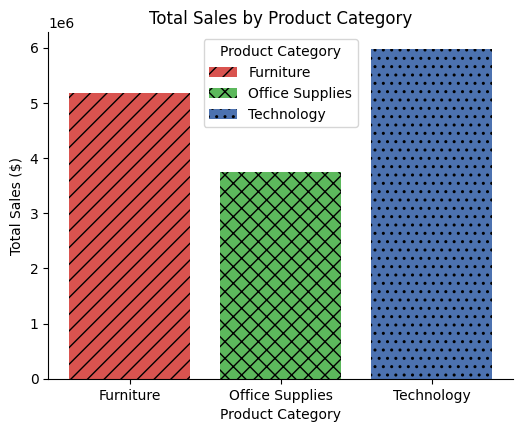

In [3]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

# TODO 1 & 2: bars with both a distinct color AND a distinct hatch pattern per category
colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for cat in cat_sales.index:
    ax.bar(cat, cat_sales[cat], color=colors[cat], hatch=hatches[cat], label=cat)

# TODO 3: legend
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Sales ($)")
ax.set_title("Total Sales by Product Category")
ax.legend(title="Product Category")
plt.show()

**Reflection:** If you only used color (no hatch pattern), which two accessibility failure modes from the lecture would this chart hit? Name both.

_Your answer:_
1.  **Colorblindness:** People with color vision deficiencies would struggle to distinguish between the different product categories if they are only differentiated by color.
2.  **Grayscale printing/display:** When printed in grayscale or viewed on a monochrome screen, all the colors would appear as shades of gray, making it impossible to differentiate the categories.

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

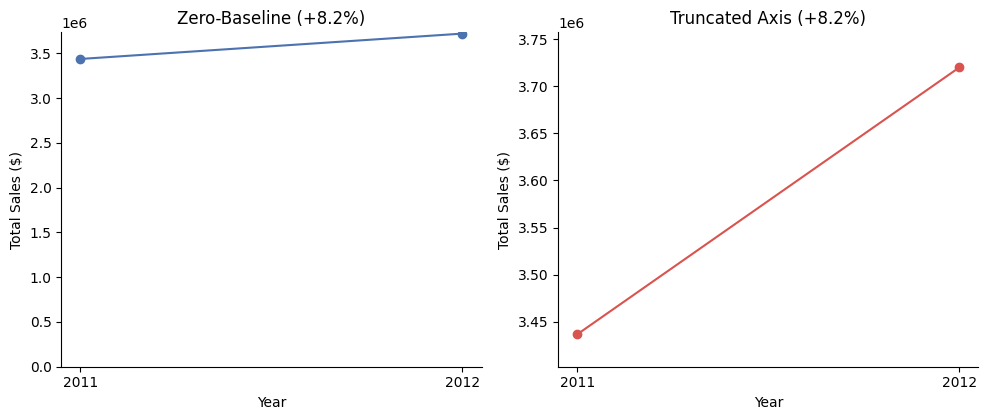

Real change from 2011 to 2012: +8.2%


In [4]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

# TODO 1 & 2: the two most recent years and their real percent change
y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales[y1], yearly_sales[y2]
pct_change = ((v2 - v1) / v1) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# TODO 3a: zero-baseline version (axes[0])
axes[0].plot(yearly_sales.loc[[y1, y2]].index, yearly_sales.loc[[y1, y2]].values, 'o-', color='#4C72B0')
axes[0].set_title(f"Zero-Baseline ({pct_change:+.1f}%)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Sales ($)")
axes[0].set_ylim(bottom=0)
axes[0].set_xticks([y1, y2])


# TODO 3b: truncated-axis version (axes[1]) -- pick tight y-limits close to v1/v2
axes[1].plot(yearly_sales.loc[[y1, y2]].index, yearly_sales.loc[[y1, y2]].values, 'o-', color='#D9534F')
axes[1].set_title(f"Truncated Axis ({pct_change:+.1f}%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Total Sales ($)")
min_val = min(v1, v2)
max_val = max(v1, v2)
axes[1].set_ylim(min_val * 0.99, max_val * 1.01) # Set tight y-limits
axes[1].set_xticks([y1, y2])

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%" if pct_change is not None else "Fill in pct_change above")

**Reflection:** Which of your two panels would you flag for the manager as potentially misleading if it were used ALONE as the report's headline chart, with no other context? Why?

_Your answer:_
I would flag the **truncated-axis version** as potentially misleading. While the actual percentage change is a modest +8.2%, the truncated axis visually exaggerates this change, making it appear much more dramatic and significant than it truly is. If presented without context, this chart could lead someone to believe that the sales increase is much larger or more impactful, potentially encouraging decisions based on an overblown perception of growth.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales increased from 2011 to 2012 by 8.2%.
INTERPRETIVE: The recent sales increase may indicate positive early returns from our new strategy.


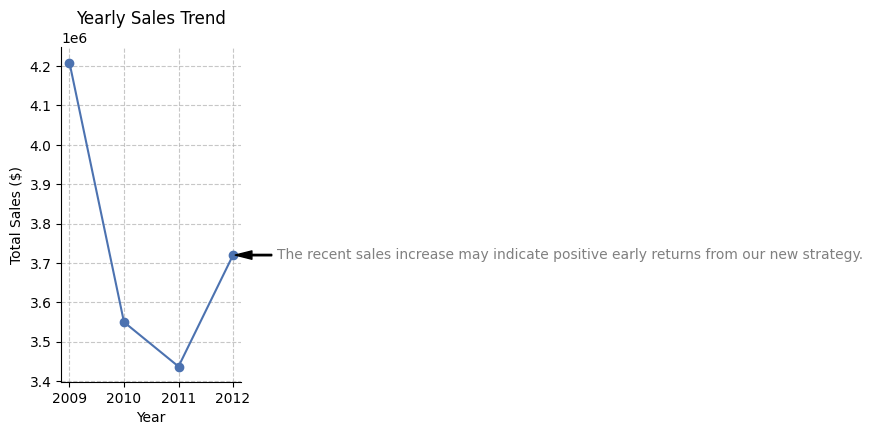

In [7]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

# TODO 1: your rewrites
descriptive_version = "Sales increased from 2011 to 2012 by 8.2%."
interpretive_version = "The recent sales increase may indicate positive early returns from our new strategy."

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

# TODO 2: plot with your interpretive annotation on the last data point
fig, ax = plt.subplots(figsize=(10, 4.3)) # Increased figure width
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
ax.set_title("Yearly Sales Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Total Sales ($)")
ax.grid(True, linestyle='--', alpha=0.7)

# Annotate the last data point with the interpretive version
ax.annotate(interpretive_version,
            xy=(yearly_sales.index[-1], yearly_sales.values[-1]),
            xytext=(yearly_sales.index[-1] + 0.8, yearly_sales.values[-1]), # Adjusted xytext to move text further right
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            ha='left', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

**Reflection:** What specific evidence would you need (that this dataset alone doesn't provide) before the ORIGINAL "proves it's working" claim would actually be justified?

_Your answer:_
To justify the claim that the new strategy "PROVES it's working," one would need several pieces of evidence that this dataset alone doesn't provide:

1.  **Causal Link:** Direct evidence establishing a causal relationship between the implementation of the new strategy and the observed sales increase. The current data only shows a correlation in time (sales increased after the strategy was presumably implemented), not causation.
2.  **Specific Strategy Details:** A clear understanding of what the "new strategy" actually entails. Without knowing the intervention, it's impossible to attribute changes to it.
3.  **Control Group/Baseline:** Data from a comparable period *before* the strategy was implemented, or from a control group where the strategy was *not* applied. This would help isolate the effect of the strategy from other market influences.
4.  **Statistical Significance:** A rigorous statistical analysis to determine if the observed increase is statistically significant and not merely due to random fluctuations or other external factors.
5.  **Long-term Trends & Other Factors:** Data over a longer period to see if the trend is sustained, and information about other potential confounding variables (e.g., economic conditions, competitor activities, marketing campaigns) that might have influenced sales.
6.  **Definition of "Working":** Clear metrics and goals that define what "working" means for the strategy. Is it just sales increase, or profit, market share, customer satisfaction, etc.? The current dataset only focuses on sales.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence sign-off note to your manager summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
  tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
  from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
  permanently adding to the team's process to prevent these four issues recurring.

_Your final recommendation here:_

Hi [Manager's Name],

I've completed the review of the regional performance report charts. The most urgent fix to ship before tomorrow is **rewriting the overreaching annotation (Task 4)**. Unsubstantiated claims can severely damage credibility and lead to misguided business decisions, making this a critical ethical concern.

Regarding the Ethical Visualization Audit, the question "*Does it highlight what's most important?*" directly applies to **Task 3 (Catching the Axis Exaggeration)**. The truncated-axis plot, if used alone, misleadingly amplifies a relatively small change, misrepresenting the true importance and magnitude of the sales increase.

To prevent these issues from recurring, I recommend implementing a mandatory **"Context and Implication Review"** step for all final charts. This review would require analysts to explicitly state the data's limitations and potential misinterpretations, ensuring that claims are always supported by evidence and visual representations are not misleading.